# Guía práctica 1

## Ejercicio 4 (a)

En ambas demostraciones se asume que el sistema está inicialmente en reposo ($y[-1] = y[-2] = 0$).

### Linealidad del sistema

Si el sistema es lineal, entonces la transformación de una combinación lineal de entradas debe ser igual a la combinación lineal de las transformaciones de esas entradas:

$$
y_3[n] = \alpha y_1[n] + \beta y_2[n] = H\{x_3[n]\} = H\{\alpha x_1[n] + \beta x_2[n]\}
$$

Luego, defino $y_1[n]$ e $y_2[n]$:

$$
y_1[n] = -a_1 y_1[n-1] -a_2 y_1[n-2] + b_0 x_1[n] 
$$

$$
y_2[n] = -a_1 y_2[n-1] -a_2 y_2[n-2] + b_0 x_2[n] 
$$

Luego, calculo la combinación lineal de las salidas:

$$
\alpha y_1[n] + \beta y_2[n] = \alpha (-a_1 y_1[n-1] -a_2 y_1[n-2] + b_0 x_1[n]) + \beta (-a_1 y_2[n-1] -a_2 y_2[n-2] + b_0 x_2[n]) =
$$

$$
= -a_1 (\alpha y_1[n-1] + \beta y_2[n-1]) - a_2 (\alpha y_1[n-2] + \beta y_2[n-2]) + b_0 (\alpha x_1[n] + \beta x_2[n])
$$

$$
= -a_1 y_3[n-1] - a_2 y_3[n-2] + b_0 x_3[n]
$$

donde se usó que la combinación lineal de las salidas en los instantes anteriores es $y_3[n-1]$ e $y_3[n-2]$, por el mismo razonamiento aplicado desde las condiciones iniciales nulas.

Estas ultimas expresiones muestran que la combinación lineal de las salidas es igual a la salida del sistema para la combinación lineal de las entradas, lo que confirma que el sistema es lineal.

### Invarianza temporal del sistema

La invarianza temporal se puede demostrar de manera similar. Si el sistema es invariante en el tiempo, entonces una entrada desplazada en el tiempo debe producir una salida desplazada en el tiempo de la misma manera:

$$
y[n-n_0] = H\{x[n-n_0]\}
$$

Para ello defino:

$$
x_4[n] = x[n-n_0]
$$

Luego, la salida correspondiente es:

$$
y_4[n] = -a_1 y_4[n-1] - a_2 y_4[n-2] + b_0 x[n-n_0]
$$

Luego, la salida desplazada de la entrada original se obtiene reemplazando $n$ por $n-n_0$ en la ecuación en diferencias, lo cual es válido porque $a_1$ y $a_2$ son constantes y no dependen de $n$:

$$
y[n-n_0] = -a_1 y[n-n_0-1] - a_2 y[n-n_0-2] + b_0 x[n-n_0]
$$

Ambas expresiones son la misma ecuación en diferencias, con la misma entrada $x[n-n_0]$ y las mismas condiciones iniciales nulas. Como la recursión tiene solución única, resulta:

$$
y_4[n] = y[n-n_0]
$$

Esto confirma que el sistema es invariante en el tiempo.

## Ejercicio 4 (b)

In [ ]:
from matplotlib.pyplot import (
    figure,
    grid,
    plot,
    show,
    stem,
    step,
    title,
    xlabel,
    ylabel,
    ylim,
)
from numpy import (
    angle,
    arange,
    argmax,
    ceil,
    convolve,
    cos,
    ones,
    pi,
    unwrap,
    zeros,
)
from scipy.signal import freqz, lfilter

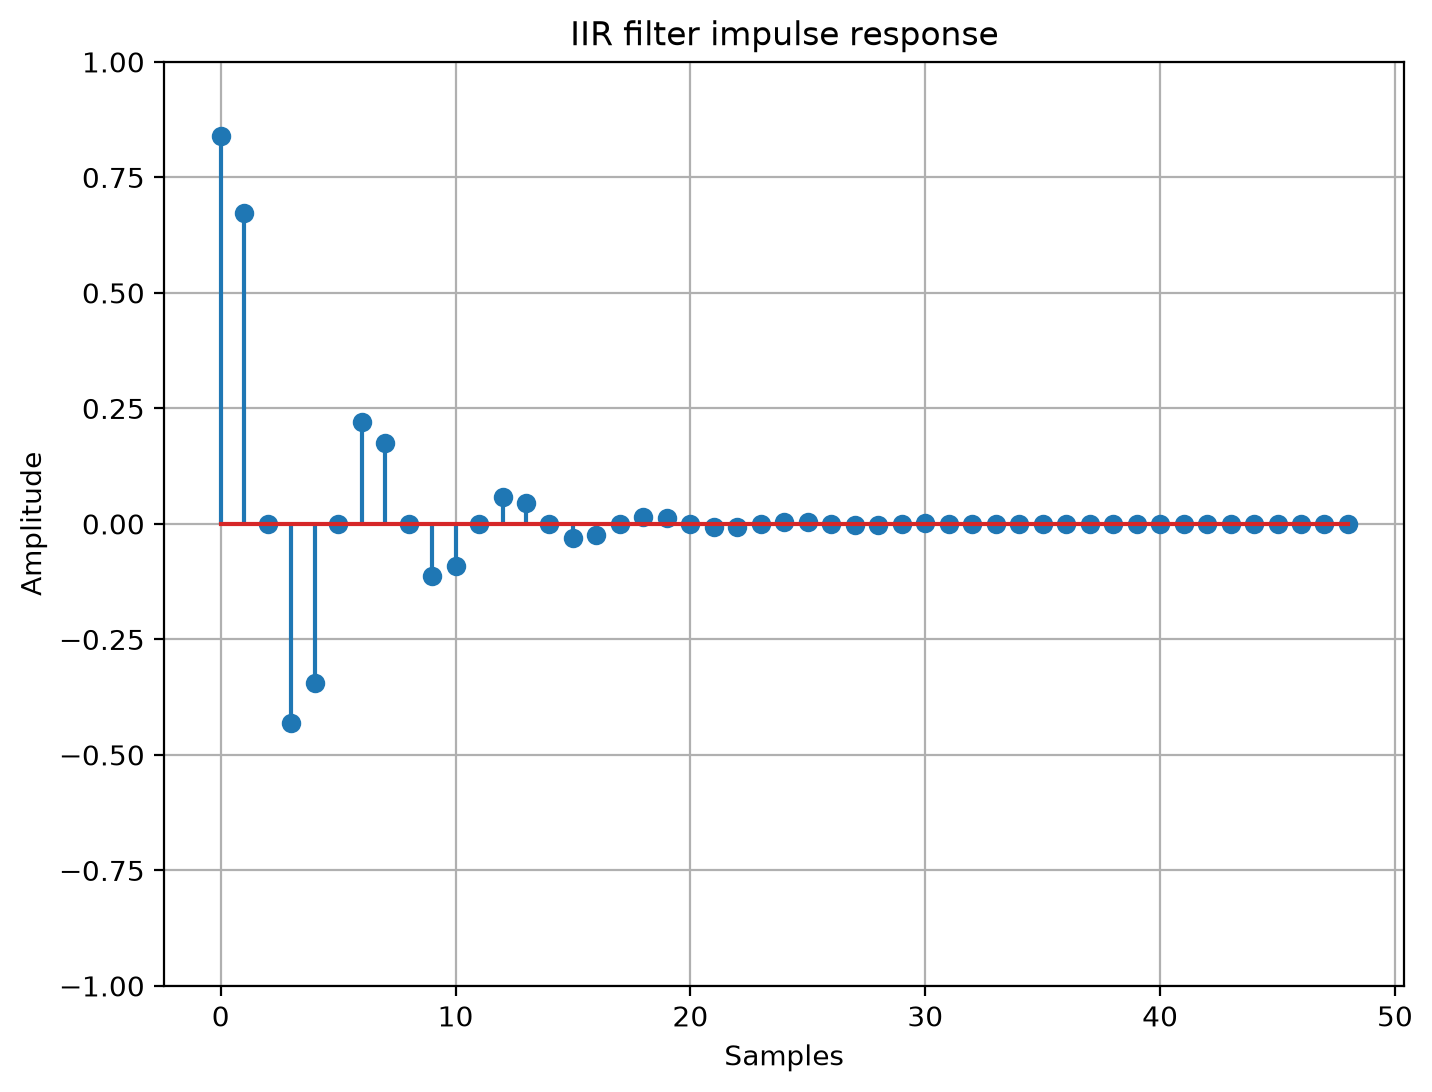

In [80]:
n_samples = 49
n = arange(n_samples)

filter_a1 = -0.8
filter_a2 = 0.64
filter_b0 = 0.84

b = [filter_b0]
a = [1, filter_a1, filter_a2]

# System input (Kronecker delta)
x = zeros(n_samples)
x[0] = 1

# System output (impulse response)
impulse_response_iir = lfilter(b, a, x)

# Manual implementation (alternative to lfilter)
# impulse_response_iir = zeros(n_samples)
# for k in range(n_samples):
#     impulse_response_iir[k] += filter_b0 * x[k]
#     if k >= 1:
#         impulse_response_iir[k] += -filter_a1 * impulse_response_iir[k - 1]
#     if k >= 2:
#         impulse_response_iir[k] += -filter_a2 * impulse_response_iir[k - 2]

figure(1, figsize=(8, 6), dpi=200)
stem(n, impulse_response_iir)
ylim((-ceil(max(impulse_response_iir)), ceil(max(impulse_response_iir))))
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter impulse response")
grid(True)
show()

## Ejercicio 4 (c)

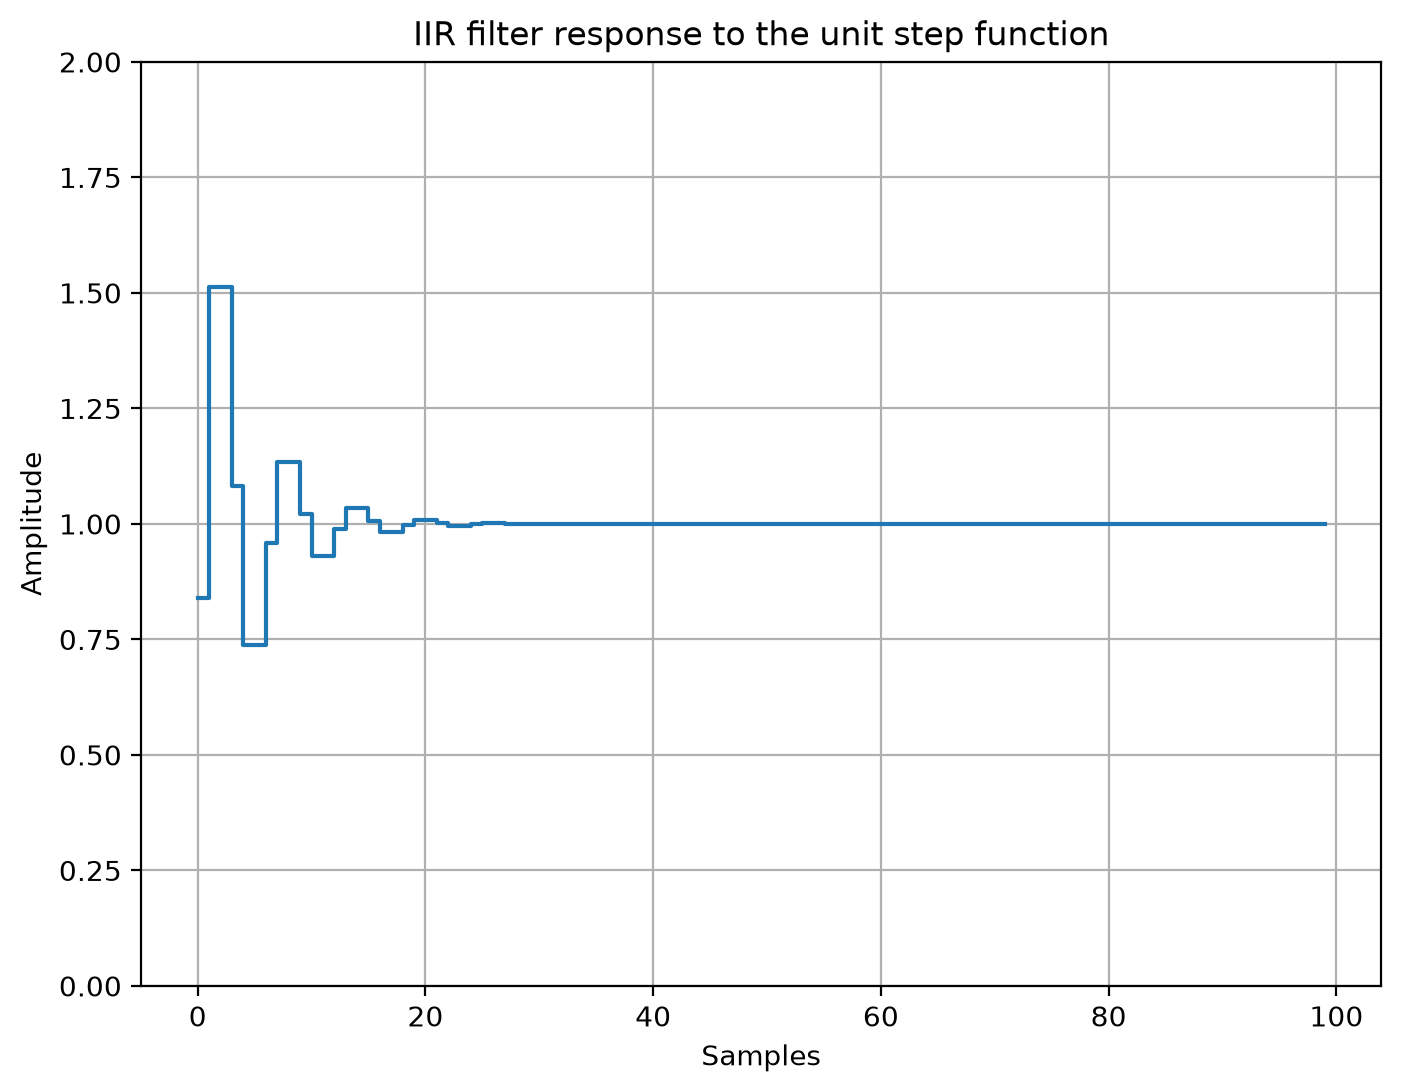

In [81]:
n_samples = 100
n = arange(n_samples)

# System input (unit step function)
x = ones(n_samples)

# System output
step_response_iir = lfilter(b, a, x)

figure(1, figsize=(8, 6), dpi=200)
step(n, step_response_iir, where="post")
ylim((0, ceil(max(step_response_iir))))
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter response to the unit step function")
grid(True)
show()

## Ejercicio 4 (d)

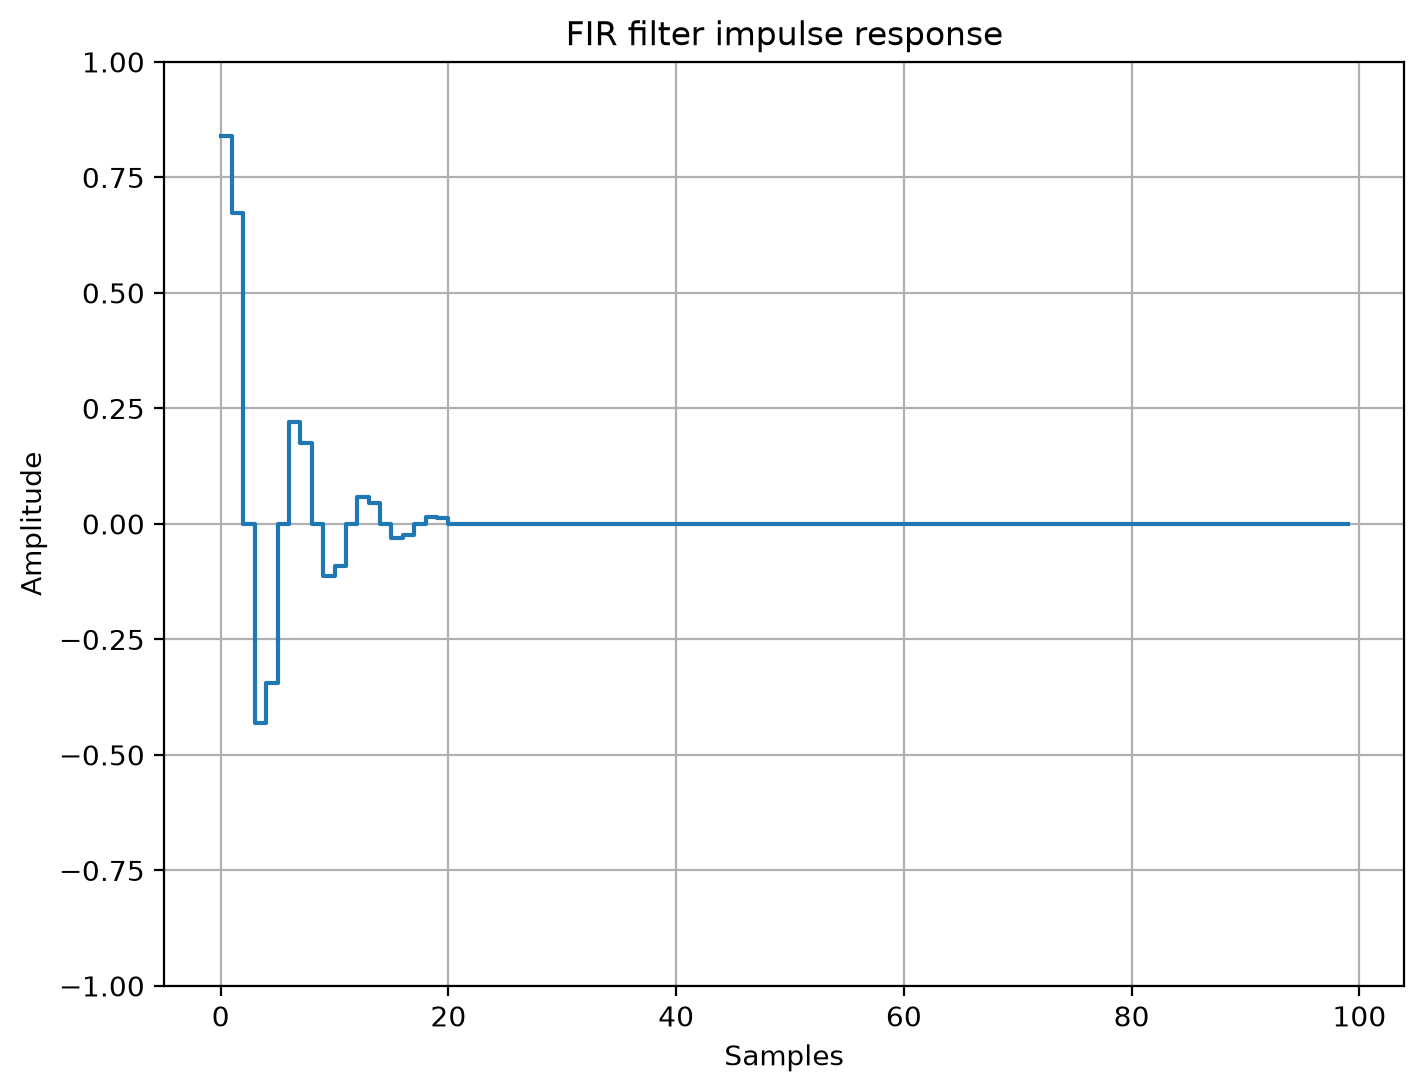

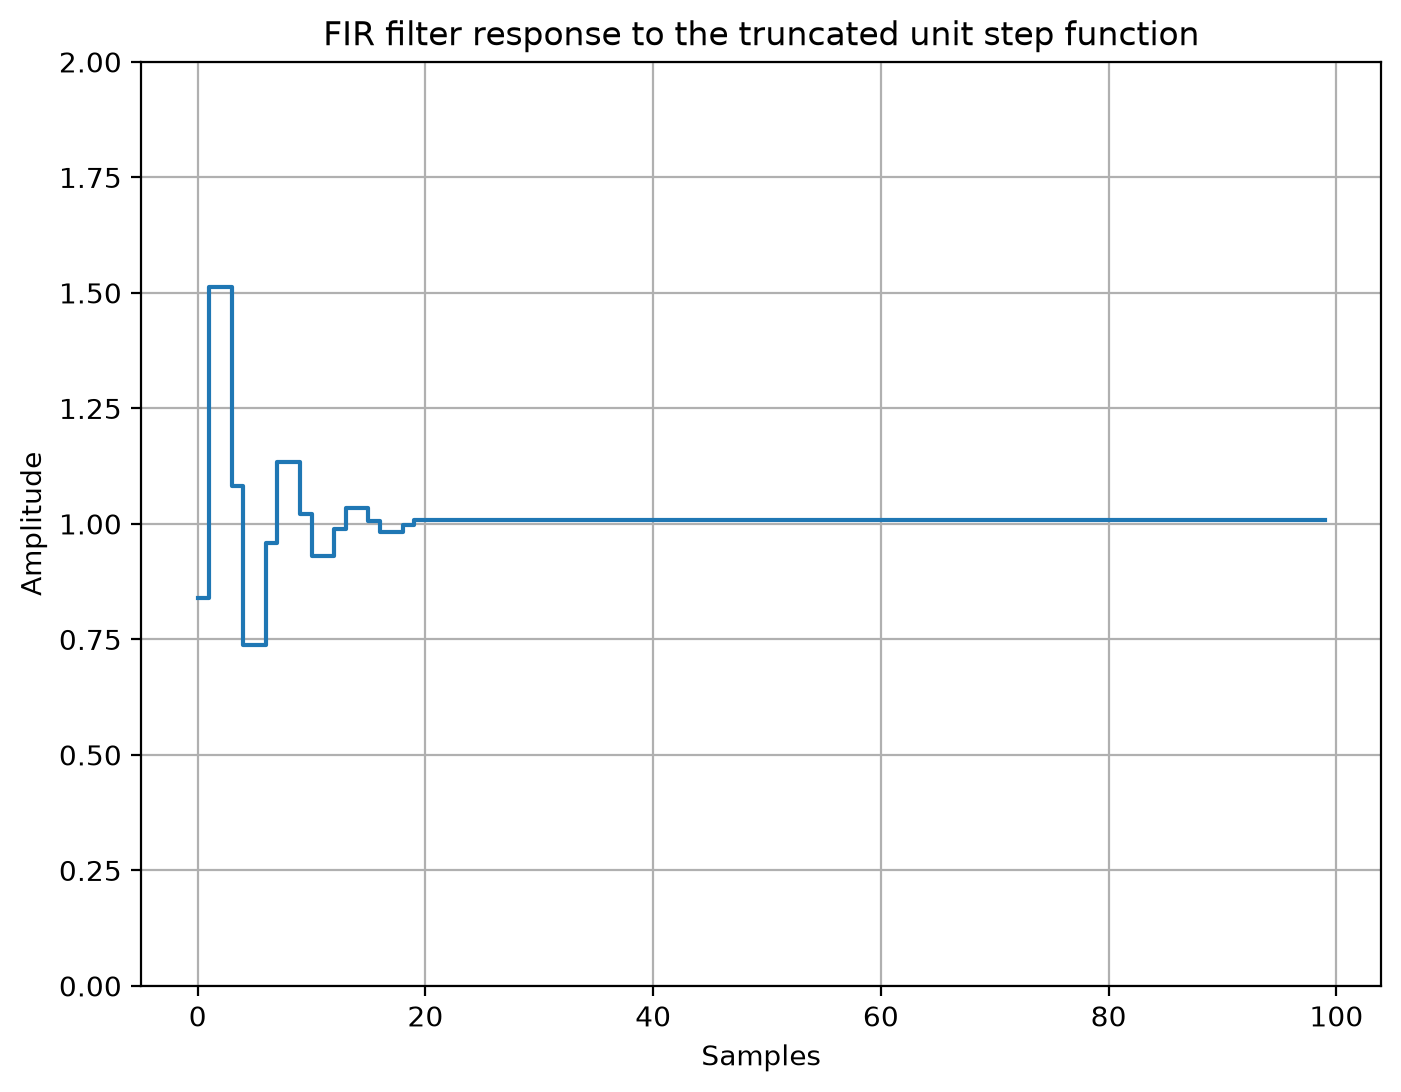

In [82]:
n_samples = 100
n = arange(n_samples)

# New filter impulse response
impulse_response_fir = zeros(n_samples)
impulse_response_fir[: 20 + 1] = impulse_response_iir[: 20 + 1]

# System input (unit step function)
x = ones(n_samples)

# System output
step_response_fir = convolve(x, impulse_response_fir)[:n_samples]

figure(1, figsize=(8, 6), dpi=200)
step(n, impulse_response_fir, where="post")
ylim((-ceil(max(impulse_response_fir)), ceil(max(impulse_response_fir))))
xlabel("Samples")
ylabel("Amplitude")
title("FIR filter impulse response")
grid(True)
show()

figure(1, figsize=(8, 6), dpi=200)
step(n, step_response_fir, where="post")
ylim((0, ceil(max(step_response_fir))))
xlabel("Samples")
ylabel("Amplitude")
title("FIR filter response to the truncated unit step function")
grid(True)
show()

## Ejercicio 4 (e)

Transformando la ecuación en diferencias con la TFTD se obtiene la siguiente expresión para la respuesta en frecuencia del sistema:

$$
Y^f(\theta) (1+ a_1 e^{-j\theta} + a_2 e^{-j2\theta}) = b_0 X^f(\theta)
$$

$$
H^f(\theta) = \frac{b_0}{1 + a_1 e^{-j\theta} + a_2 e^{-j2\theta}}
$$

Graficando módulo y fase de esta respuesta se puede determinar fácilmente que se trata de un filtro pasabanda con un pico en la banda de paso en $\pi/3$.

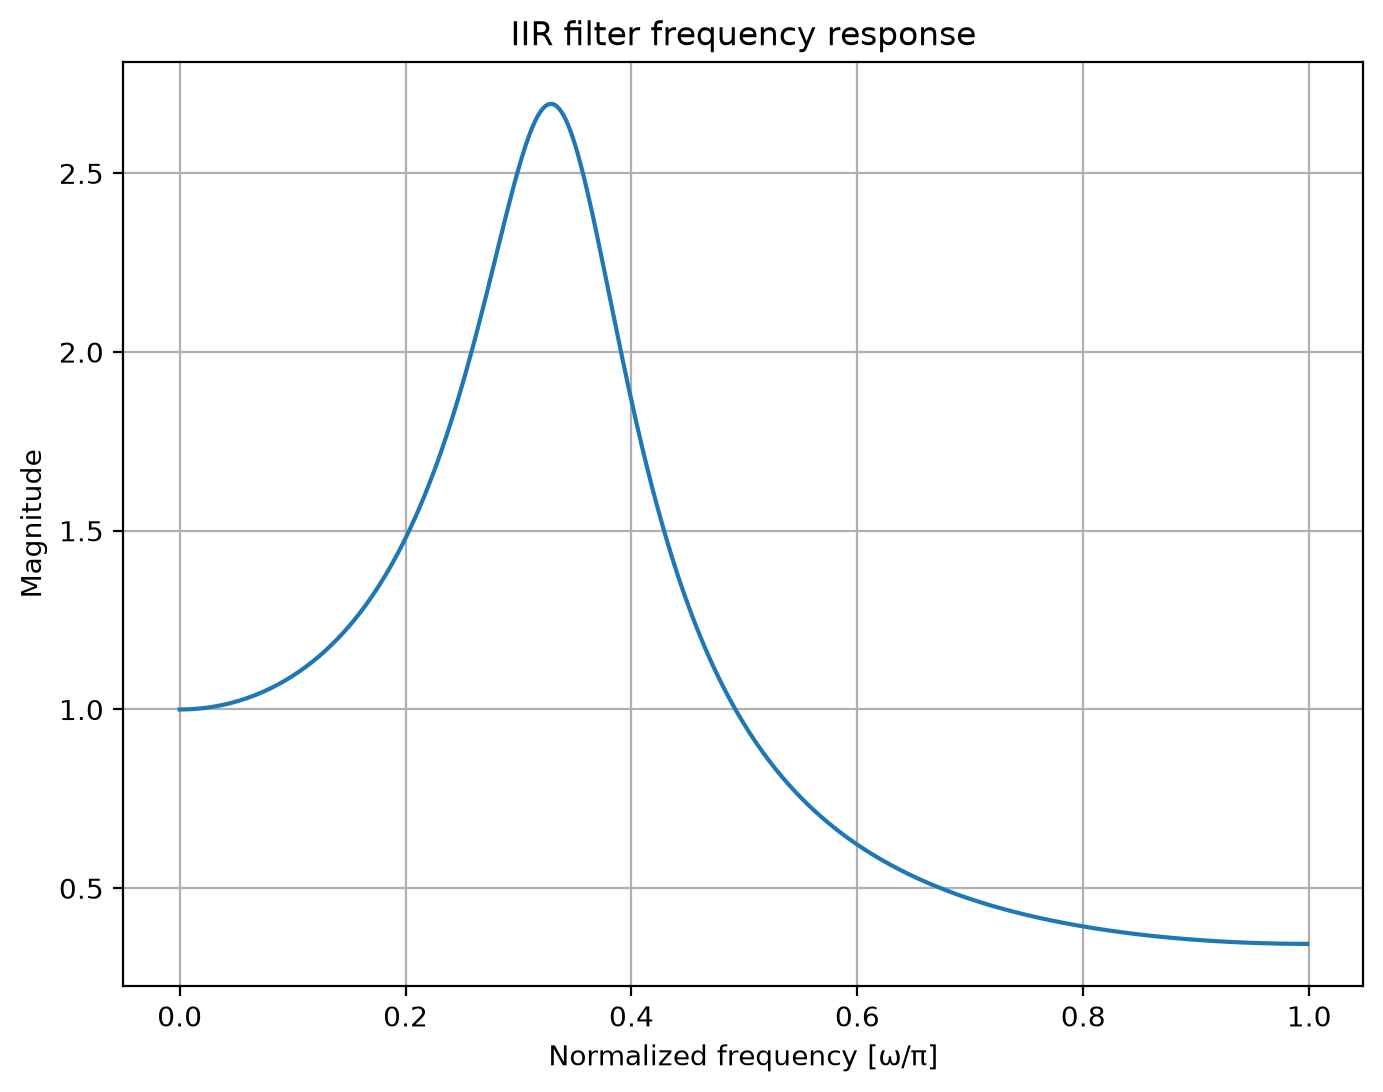

1.030835089459151


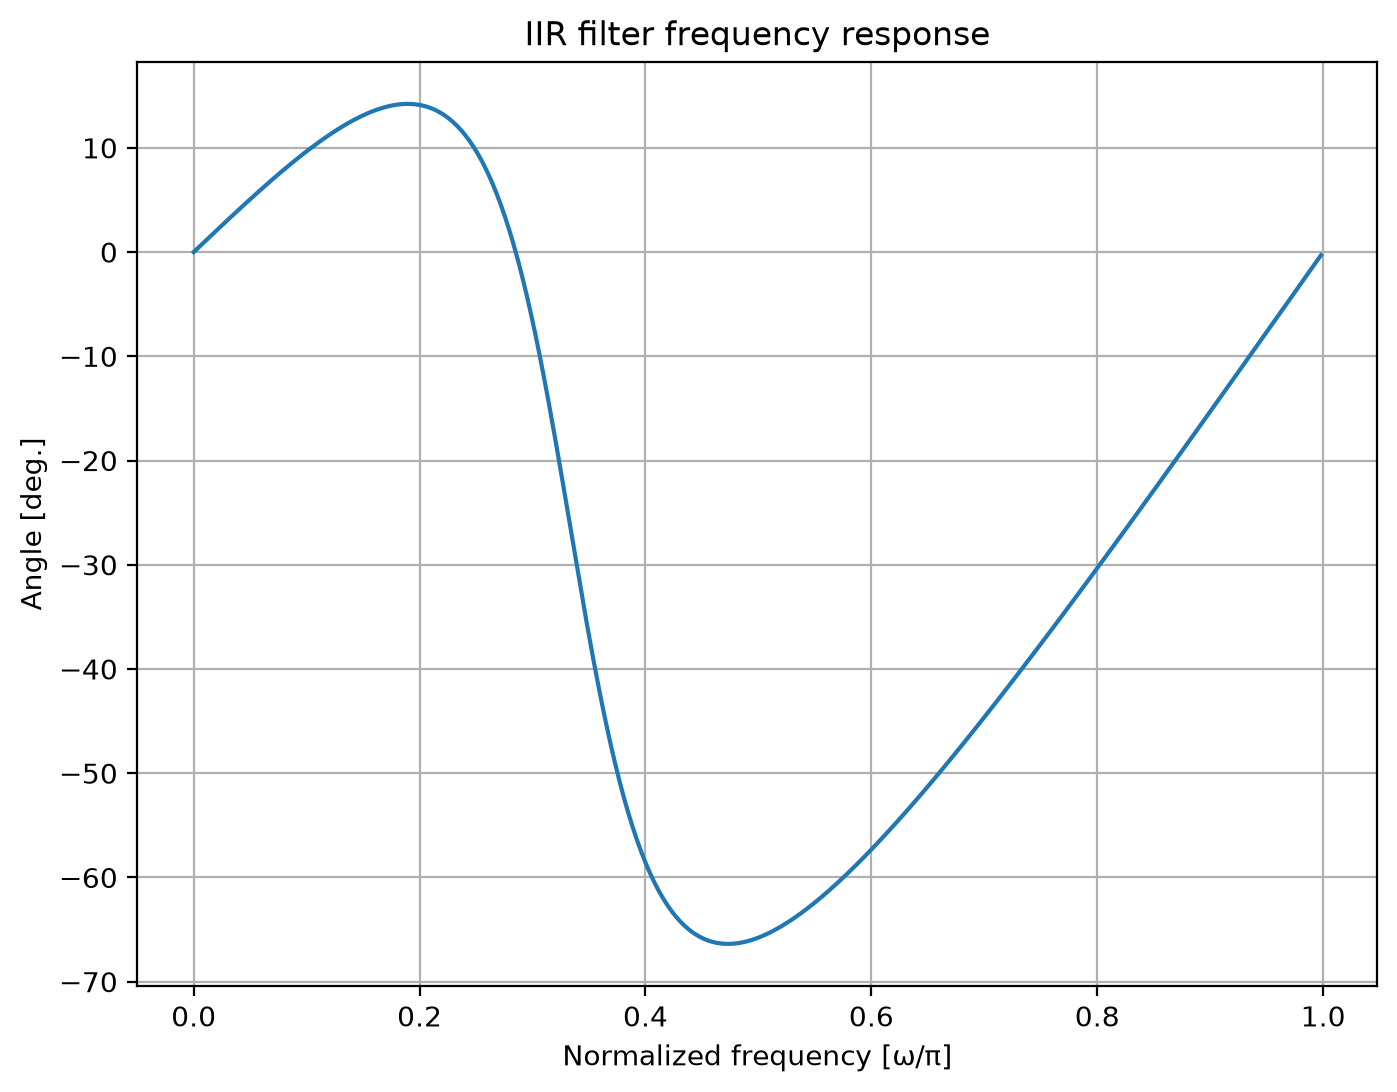

In [ ]:
w, H = freqz(b, a)

figure(1, figsize=(8, 6), dpi=200)
plot(w / pi, abs(H))
xlabel("Normalized frequency [ω/π]")
ylabel("Magnitude")
title("IIR filter frequency response")
grid(True)
show()

figure(1, figsize=(8, 6), dpi=200)
plot(w / pi, unwrap(angle(H)) * 180 / pi)
xlabel("Normalized frequency [ω/π]")
ylabel("Angle [deg.]")
title("IIR filter frequency response")
grid(True)
show()

## Ejercicio 4 (f)

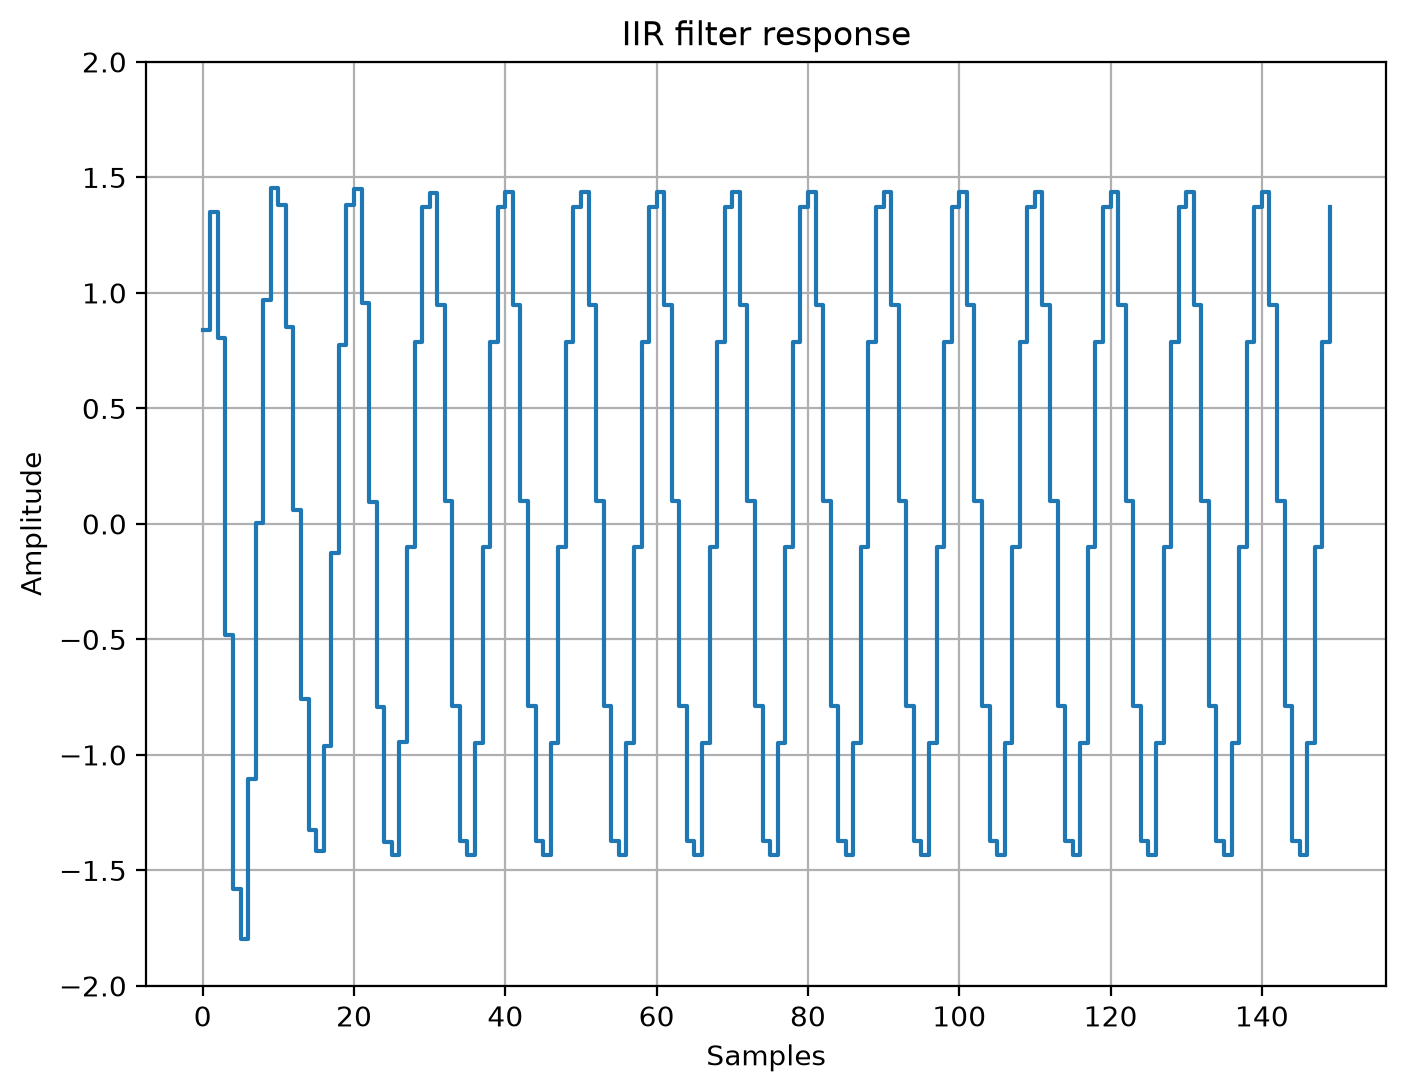

In [86]:
n_samples = 150
n = arange(n_samples)

x = cos(2 * pi * n / 10)
y = convolve(x, impulse_response_iir)[:n_samples]

figure(1, figsize=(8, 6), dpi=200)
step(n, y, where="post")
ylim((-ceil(max(y)), ceil(max(y))))
xlabel("Samples")
ylabel("Amplitude")
title("IIR filter response")
grid(True)
show()